In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('./resources/ushape.csv' , names=['X', 'Y','class'])

In [22]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


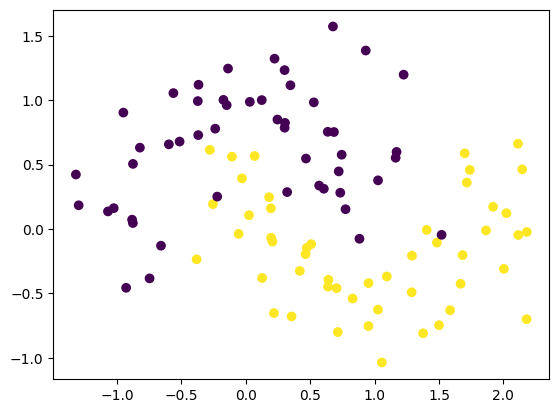

In [23]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [24]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [25]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [26]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_uniform'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

c:\Users\mrsan\OneDrive\Desktop\code\python\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.get_weights()

[array([[-0.39649856, -1.1189257 , -0.08028758, -1.3678683 ,  1.3962649 ,
          0.2810601 , -1.6233293 ,  0.36423743, -1.0671273 , -0.57916796],
        [-0.8963246 ,  0.9808878 ,  0.9427711 , -0.38795376, -1.1635994 ,
          1.2442433 , -0.92528665, -0.94032764, -0.647223  ,  1.1986314 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.5416804 ,  0.17113443,  0.56797904, -0.5932048 ,  0.6579624 ,
         -0.60649794,  0.17075317, -0.42229652,  0.50091827,  0.09561662],
        [-0.01232336, -0.29684332, -0.90748495, -0.11954768, -0.04825117,
         -0.05961473, -1.0100297 ,  0.5684989 ,  0.06492218,  0.08336285],
        [ 0.07079334,  0.13953182, -0.02480178,  0.31097162, -0.86111116,
         -0.18313588, -0.1963484 ,  0.35399124,  0.49737632,  0.02605364],
        [-0.16800568,  0.16736956, -0.30907735,  0.7318774 , -0.9512306 ,
          0.00200122,  0.18123935,  0.05380725, -0.9063502 , -0.29502162],
        [-0.62752

In [28]:
initial_weights = model.get_weights()

In [29]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [30]:
model.set_weights(initial_weights)

In [31]:
model.get_weights()

[array([[-0.07427418,  1.4027894 ,  0.87392455, -0.05477007, -0.16960888,
         -0.3907839 , -0.5571688 , -0.12977517, -1.7557055 , -0.02588006],
        [ 1.0139395 ,  0.03048843,  1.9755036 , -0.6904983 , -0.6418141 ,
         -0.21635115,  0.41814268,  0.38906622, -1.5110483 , -0.5659651 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.10055149, -0.61826384,  0.25212157,  0.34498098,  0.0174916 ,
          0.20049213,  0.221483  , -0.4386489 , -0.37207893,  0.77387005],
        [-0.24589497,  0.03488396,  0.01416105,  0.6110124 ,  0.07259427,
         -0.23219116,  0.03475596, -0.05504525, -0.03875815,  0.34775037],
        [ 0.57036525, -0.27553967,  0.28973597,  0.0577007 , -0.09077666,
          0.3187314 ,  0.38793287,  0.25497484, -0.40651587, -0.26785928],
        [-0.11026655, -0.6737837 ,  0.27169847, -1.0397499 , -0.39743492,
          0.02837505,  0.48563582, -0.1924329 , -0.2814352 ,  0.24526648],
        [ 0.06159

In [32]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [33]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.5000 - loss: 0.7190 - val_accuracy: 0.5000 - val_loss: 0.6998
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.7075 - val_accuracy: 0.5000 - val_loss: 0.6890
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5000 - loss: 0.6978 - val_accuracy: 0.5000 - val_loss: 0.6794
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.6887 - val_accuracy: 0.5000 - val_loss: 0.6703
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.6802 - val_accuracy: 0.5500 - val_loss: 0.6618
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5125 - loss: 0.6720 - val_accuracy: 0.5000 - val_loss: 0.6538
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5125 - loss: 0.6646 - val_accuracy: 0.5500 - val_loss: 0.6470
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5125 - loss: 0.6576 - val_accuracy: 0.5500 - val_loss

In [34]:
model.get_weights()

[array([[-0.20698588,  1.4568079 ,  0.80712664, -0.02103387, -0.16953307,
         -0.58373123, -0.65286905, -0.17289719, -2.009826  ,  0.08053255],
        [ 1.1489726 , -0.05919442,  2.117695  , -0.6856998 , -0.67395926,
         -0.18901734,  0.55755174,  0.5759141 , -1.2917556 , -0.72270143]],
       dtype=float32),
 array([ 0.04659558, -0.08921909,  0.04278972, -0.01288495,  0.04980041,
        -0.03048505,  0.00348844,  0.13675588,  0.07274691,  0.11770637],
       dtype=float32),
 array([[ 3.32870483e-01, -6.18263841e-01,  4.23163265e-01,
          1.72747418e-01,  2.19176915e-02,  3.33079308e-01,
          3.55989009e-01, -4.12281543e-01, -3.72078925e-01,
          8.23426187e-01],
        [-3.71842831e-01,  3.48839611e-02, -5.96326776e-02,
          6.42405570e-01,  1.29825071e-01, -1.75398901e-01,
         -6.20632730e-02,  1.94820255e-01, -3.87581512e-02,
          3.98581237e-01],
        [ 5.77296793e-01, -2.75539666e-01,  2.49625802e-01,
          2.22058147e-02, -6.31753

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

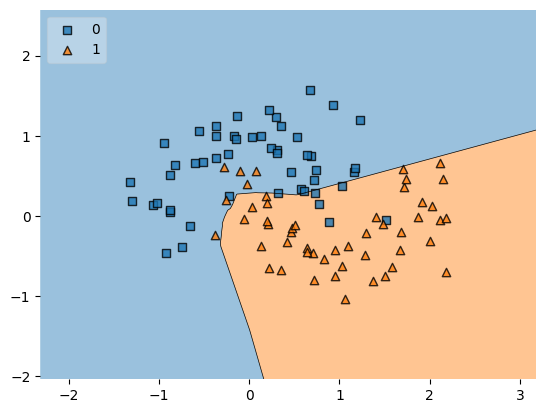

In [35]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [36]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.02356461012026382)

In [37]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.02209247234638155)